In [16]:
!pip install pandas seaborn matplotlib scikit-learn nltk

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/IMDB Dataset.csv'
df = pd.read_csv(file_path)

# Display basic information
print("Dataset Shape:", df.shape)
display(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Missing Values:
review       0
sentiment    0
dtype: int64


In [18]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 2. Remove non-alphabetic characters and convert to lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    # 3. Tokenize and remove stopwords, then lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return ' '.join(cleaned_words)

# Apply the cleaning function to the review column
print("Cleaning reviews... this may take a minute.")
df['cleaned_review'] = df['review'].apply(clean_text)

# Show comparison
display(df[['review', 'cleaned_review']].head())
print("Preprocessing Complete!")

Cleaning reviews... this may take a minute.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


Preprocessing Complete!


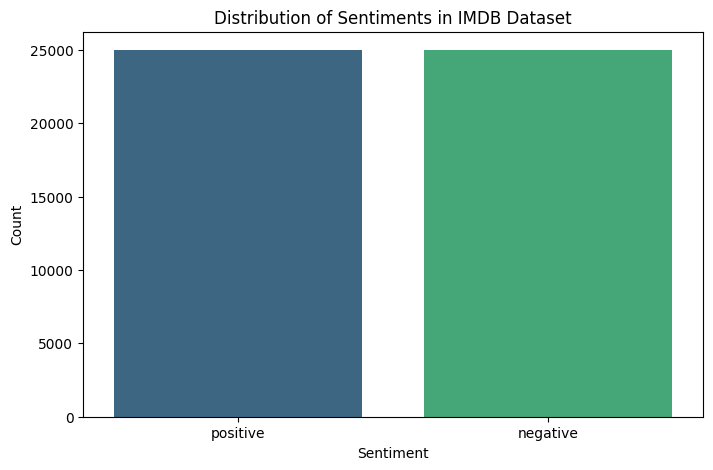

Sentiment Value Counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [19]:
# Visualize Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='viridis', hue='sentiment', legend=False)
plt.title('Distribution of Sentiments in IMDB Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Check exact counts
print("Sentiment Value Counts:")
print(df['sentiment'].value_counts())

In [20]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize cleaning tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove non-alphabetic characters and lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    # Tokenize, remove stopwords, and lemmatize
    words = text.split()
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(cleaned)

# Apply cleaning to the dataset
print('Cleaning reviews... please wait.')
df['cleaned_review'] = df['review'].apply(clean_text)

# Preview the transformation
print('Preprocessing complete!')
display(df[['review', 'cleaned_review']].head())

Cleaning reviews... please wait.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Preprocessing complete!


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Ensure the cleaned_review column exists (re-running cleaning if necessary)
if 'cleaned_review' not in df.columns:
    print('Cleaning reviews again to ensure column existence...')
    df['cleaned_review'] = df['review'].apply(clean_text)

# 1. Encode labels (positive -> 1, negative -> 0)
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

# 2. Split the dataset (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_review'], y, test_size=0.2, random_state=42
)

# 3. Bag of Words (BoW) Vectorization
cv = CountVectorizer(max_features=5000)
X_train_bow = cv.fit_transform(X_train_raw)
X_test_bow = cv.transform(X_test_raw)

# 4. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print('Vectorization Complete!')
print(f'BoW Shape: {X_train_bow.shape}')
print(f'TF-IDF Shape: {X_train_tfidf.shape}')

Vectorization Complete!
BoW Shape: (40000, 5000)
TF-IDF Shape: (40000, 5000)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Initialize models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
nb_model = MultinomialNB()
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Train Logistic Regression
print('Training Logistic Regression...')
lr_model.fit(X_train_tfidf, y_train)

# Train Naive Bayes
print('Training Naive Bayes...')
nb_model.fit(X_train_tfidf, y_train)

# Train Decision Tree
print('Training Decision Tree...')
dt_model.fit(X_train_tfidf, y_train)

print('Model Training Complete!')

Training Logistic Regression...
Training Naive Bayes...
Training Decision Tree...
Model Training Complete!


In [24]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Define a helper function to evaluate models
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"--- {name} Performance ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    return acc, f1

# Evaluate all models
lr_results = evaluate_model(lr_model, X_test_tfidf, y_test, "Logistic Regression")
nb_results = evaluate_model(nb_model, X_test_tfidf, y_test, "Multinomial Naive Bayes")
dt_results = evaluate_model(dt_model, X_test_tfidf, y_test, "Decision Tree")

# Create a comparison summary
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
    'Accuracy': [lr_results[0], nb_results[0], dt_results[0]],
    'F1-Score': [lr_results[1], nb_results[1], dt_results[1]]
})

print("\nSummary Comparison:")
display(comparison_df.sort_values(by='Accuracy', ascending=False))

--- Logistic Regression Performance ---
Accuracy: 0.8890
F1-Score: 0.8913
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

--- Multinomial Naive Bayes Performance ---
Accuracy: 0.8546
F1-Score: 0.8566
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4961
           1       0.85      0.86      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

--- Decision Tree Performance ---
Accuracy: 0.7334
F1-Score: 0.7615
              precision    recall  f1-score   support

           0       0.80      0.62      0.70      4961
           1     

,Model,Accuracy,F1-Score
0,Logistic Regression,0.8890,0.891347
1,Naive Bayes,0.8546,0.856607
2,Decision Tree,0.7334,0.761538


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Initialize models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
nb_model = MultinomialNB()
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)

# Train models on TF-IDF data
print('Training Logistic Regression...')
lr_model.fit(X_train_tfidf, y_train)

print('Training Naive Bayes...')
nb_model.fit(X_train_tfidf, y_train)

print('Training Decision Tree...')
dt_model.fit(X_train_tfidf, y_train)

print('Model Training Complete!')

Training Logistic Regression...
Training Naive Bayes...
Training Decision Tree...
Model Training Complete!
